# Solar Power Forecasting — Plant 2: Exploration and Modeling

This notebook applies the same forecasting approach used for Plant 1 to Plant 2, and also documents a data quality issue specific to Plant 2: `DAILY_YIELD` doesn't reset to 0 at midnight for some inverters, so it can't be used directly as a feature.


In [1]:
# Section 1: Imports and setup
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import logging
import seaborn as sns
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, r2_score

plt.style.use('seaborn-v0_8-whitegrid') if 'seaborn-v0_8-whitegrid' in plt.style.available else plt.style.use('ggplot')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s [%(levelname)s] %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S'
)
logger = logging.getLogger("solar_forecast")


## 2. Load data

Load Plant 2's generation and weather CSVs and parse timestamps.


In [2]:
# Section 2: Load data
gen_path = '../data/raw/Plant_2_Generation_Data.csv' if os.path.exists('../data/raw/Plant_2_Generation_Data.csv') else 'Plant_2_Generation_Data.csv'
weather_path = '../data/raw/Plant_2_Weather_Sensor_Data.csv' if os.path.exists('../data/raw/Plant_2_Weather_Sensor_Data.csv') else 'Plant_2_Weather_Sensor_Data.csv'

gen_p2 = pd.read_csv(gen_path)
weather_p2 = pd.read_csv(weather_path)

gen_p2['DATE_TIME'] = pd.to_datetime(gen_p2['DATE_TIME'])
weather_p2['DATE_TIME'] = pd.to_datetime(weather_p2['DATE_TIME'])

gen_p2['DATE_STR'] = gen_p2['DATE_TIME'].dt.strftime('%Y-%m-%d')
gen_p2['TIME_STR'] = gen_p2['DATE_TIME'].dt.strftime('%H:%M')


## 3. Schema check

Print row counts, columns, and a sample of each dataset.


In [3]:
# Section 3: Schema check
print("Generation data:")
print(f"  Rows: {gen_p2.shape[0]}")
print(f"  Columns: {list(gen_p2.columns)}")
print(gen_p2.head(3).to_string(index=False))

print("\nWeather data:")
print(f"  Rows: {weather_p2.shape[0]}")
print(f"  Columns: {list(weather_p2.columns)}")
print(weather_p2.head(3).to_string(index=False))


Generation data:
  Rows: 67698
  Columns: ['DATE_TIME', 'PLANT_ID', 'SOURCE_KEY', 'DC_POWER', 'AC_POWER', 'DAILY_YIELD', 'TOTAL_YIELD', 'DATE_STR', 'TIME_STR']
 DATE_TIME  PLANT_ID      SOURCE_KEY  DC_POWER  AC_POWER  DAILY_YIELD  TOTAL_YIELD   DATE_STR TIME_STR
2020-05-15   4136001 4UPUqMRk7TRMgml       0.0       0.0  9425.000000    2429011.0 2020-05-15    00:00
2020-05-15   4136001 81aHJ1q11NBPMrL       0.0       0.0     0.000000 1215278736.0 2020-05-15    00:00
2020-05-15   4136001 9kRcWv60rDACzjR       0.0       0.0  3075.333333 2247719577.0 2020-05-15    00:00

Weather data:
  Rows: 3259
  Columns: ['DATE_TIME', 'PLANT_ID', 'SOURCE_KEY', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']
          DATE_TIME  PLANT_ID      SOURCE_KEY  AMBIENT_TEMPERATURE  MODULE_TEMPERATURE  IRRADIATION
2020-05-15 00:00:00   4136001 iq8k7ZNt4Mwm3w0            27.004764           25.060789          0.0
2020-05-15 00:15:00   4136001 iq8k7ZNt4Mwm3w0            26.880811           24.421869   

## 4. DC vs AC power on a single day

Same sanity check as Plant 1: plot one day (`2020-05-25`) averaged across all inverters.


2026-07-05 16:59:53 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-05 16:59:53 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-05 16:59:53 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-05 16:59:53 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


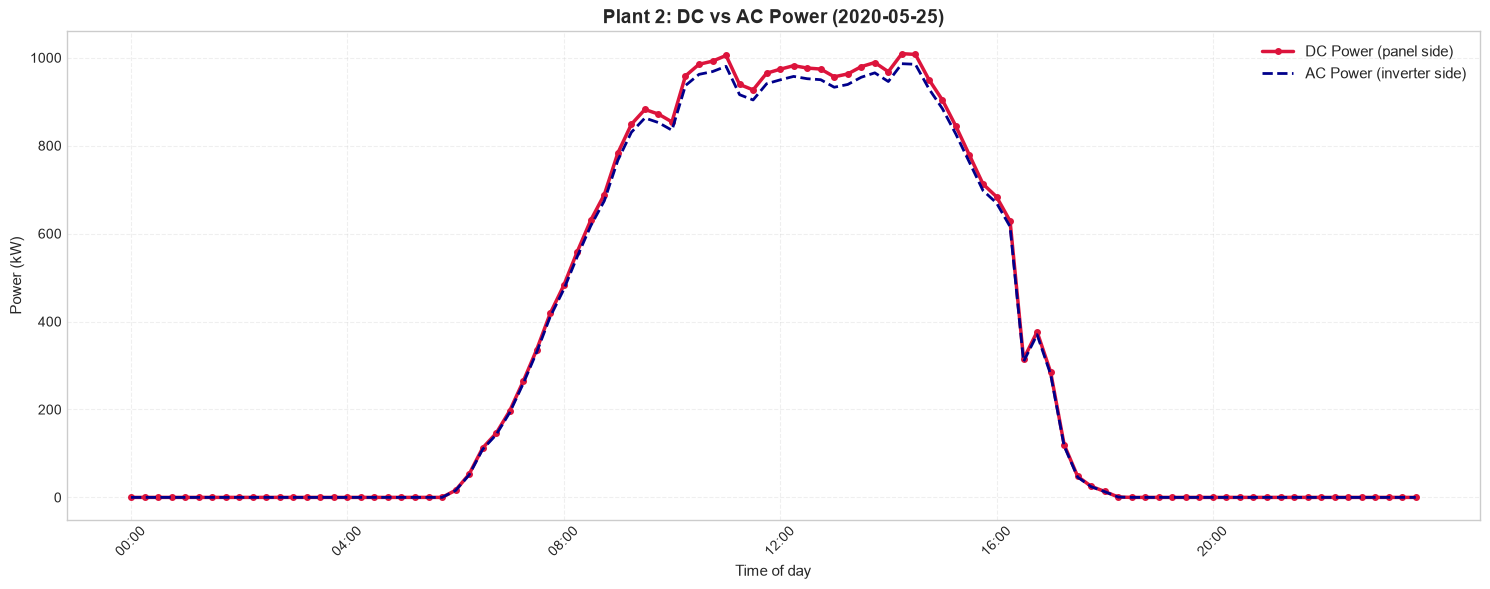

In [4]:
# Section 4: DC vs AC power for one day
target_sample_date = '2020-05-25'
single_day_gen = gen_p2[gen_p2['DATE_STR'] == target_sample_date].sort_values('DATE_TIME')
single_day_profile = single_day_gen.groupby('TIME_STR')[['DC_POWER', 'AC_POWER']].mean().reset_index()

plt.figure(figsize=(15, 6))
plt.plot(single_day_profile['TIME_STR'], single_day_profile['DC_POWER'],
         color='crimson', lw=2.5, marker='o', ms=4, label='DC Power (panel side)')
plt.plot(single_day_profile['TIME_STR'], single_day_profile['AC_POWER'],
         color='darkblue', lw=2, linestyle='--', label='AC Power (inverter side)')

# Show a tick every 4 hours
ax1 = plt.gca()
current_ticks = ax1.get_xticks()
ax1.set_xticks(current_ticks[::16])
plt.xticks(rotation=45)

plt.title(f"Plant 2: DC vs AC Power ({target_sample_date})", fontsize=14, fontweight='bold')
plt.xlabel("Time of day", fontsize=11)
plt.ylabel("Power (kW)", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='upper right', fontsize=11)
plt.tight_layout()
plt.show()


## 5. One inverter's daily and cumulative yield

Pick a single inverter and plot its daily yield (bars) alongside its lifetime cumulative yield (line) to check the counters behave as expected.


2026-07-05 16:59:53 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-05 16:59:53 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-05 16:59:53 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-05 16:59:53 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


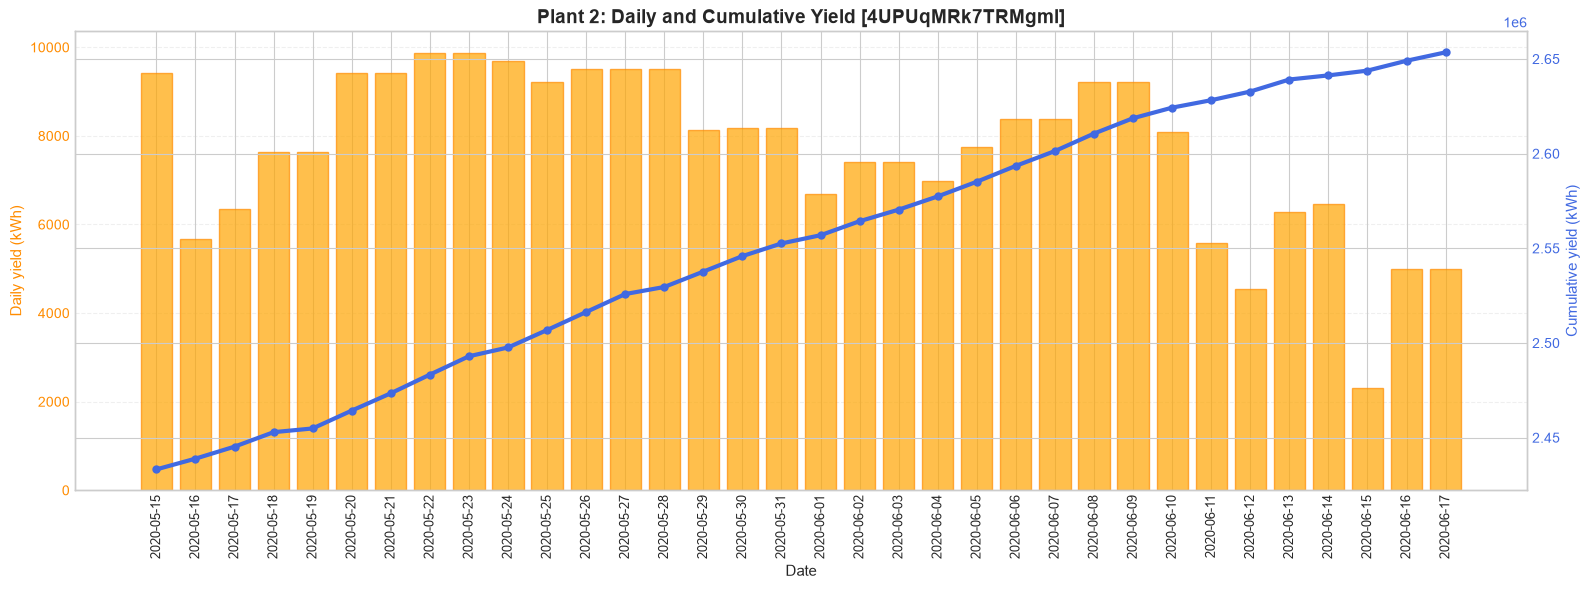

In [5]:
# Section 5: One inverter's daily and cumulative yield
target_asset = gen_p2['SOURCE_KEY'].unique()[0]
asset_df = gen_p2[gen_p2['SOURCE_KEY'] == target_asset].sort_values('DATE_TIME')

daily_summary = asset_df.groupby('DATE_STR').agg({
    'DAILY_YIELD': 'max',
    'TOTAL_YIELD': 'max'
}).reset_index()

fig, ax1 = plt.subplots(figsize=(16, 6))

ax1.bar(daily_summary['DATE_STR'], daily_summary['DAILY_YIELD'],
        color='orange', edgecolor='darkorange', alpha=0.7, label='Daily yield (kWh)')
ax1.set_xlabel("Date", fontsize=11)
ax1.set_ylabel("Daily yield (kWh)", color='darkorange', fontsize=11)
ax1.tick_params(axis='y', labelcolor='darkorange')

x_indices = np.arange(len(daily_summary['DATE_STR']))
ax1.set_xticks(x_indices)
ax1.set_xticklabels(daily_summary['DATE_STR'], rotation=90, fontsize=9)
ax1.grid(True, axis='y', linestyle='--', alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(daily_summary['DATE_STR'], daily_summary['TOTAL_YIELD'],
         color='royalblue', lw=3, marker='o', ms=5, label='Cumulative total yield (kWh)')
ax2.set_ylabel("Cumulative yield (kWh)", color='royalblue', fontsize=11)
ax2.tick_params(axis='y', labelcolor='royalblue')

plt.title(f"Plant 2: Daily and Cumulative Yield [{target_asset}]", fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()


## 6. Weather feature summary statistics

Summary stats for ambient temperature, module temperature, and irradiation, ahead of building the model.


In [6]:
# Section 6: Weather feature summary statistics
weather_metrics = ['AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']
print(weather_p2[weather_metrics].describe().to_string())


       AMBIENT_TEMPERATURE  MODULE_TEMPERATURE  IRRADIATION
count          3259.000000         3259.000000  3259.000000
mean             28.069400           32.772408     0.232737
std               4.061556           11.344034     0.312693
min              20.942385           20.265123     0.000000
25%              24.602135           23.716881     0.000000
50%              26.981263           27.534606     0.019040
75%              31.056757           40.480653     0.438717
max              39.181638           66.635953     1.098766


## 7. Weather feature distributions

Histograms and boxplots for each weather feature. Irradiation should show a large mass at 0 W/m² for nighttime readings.


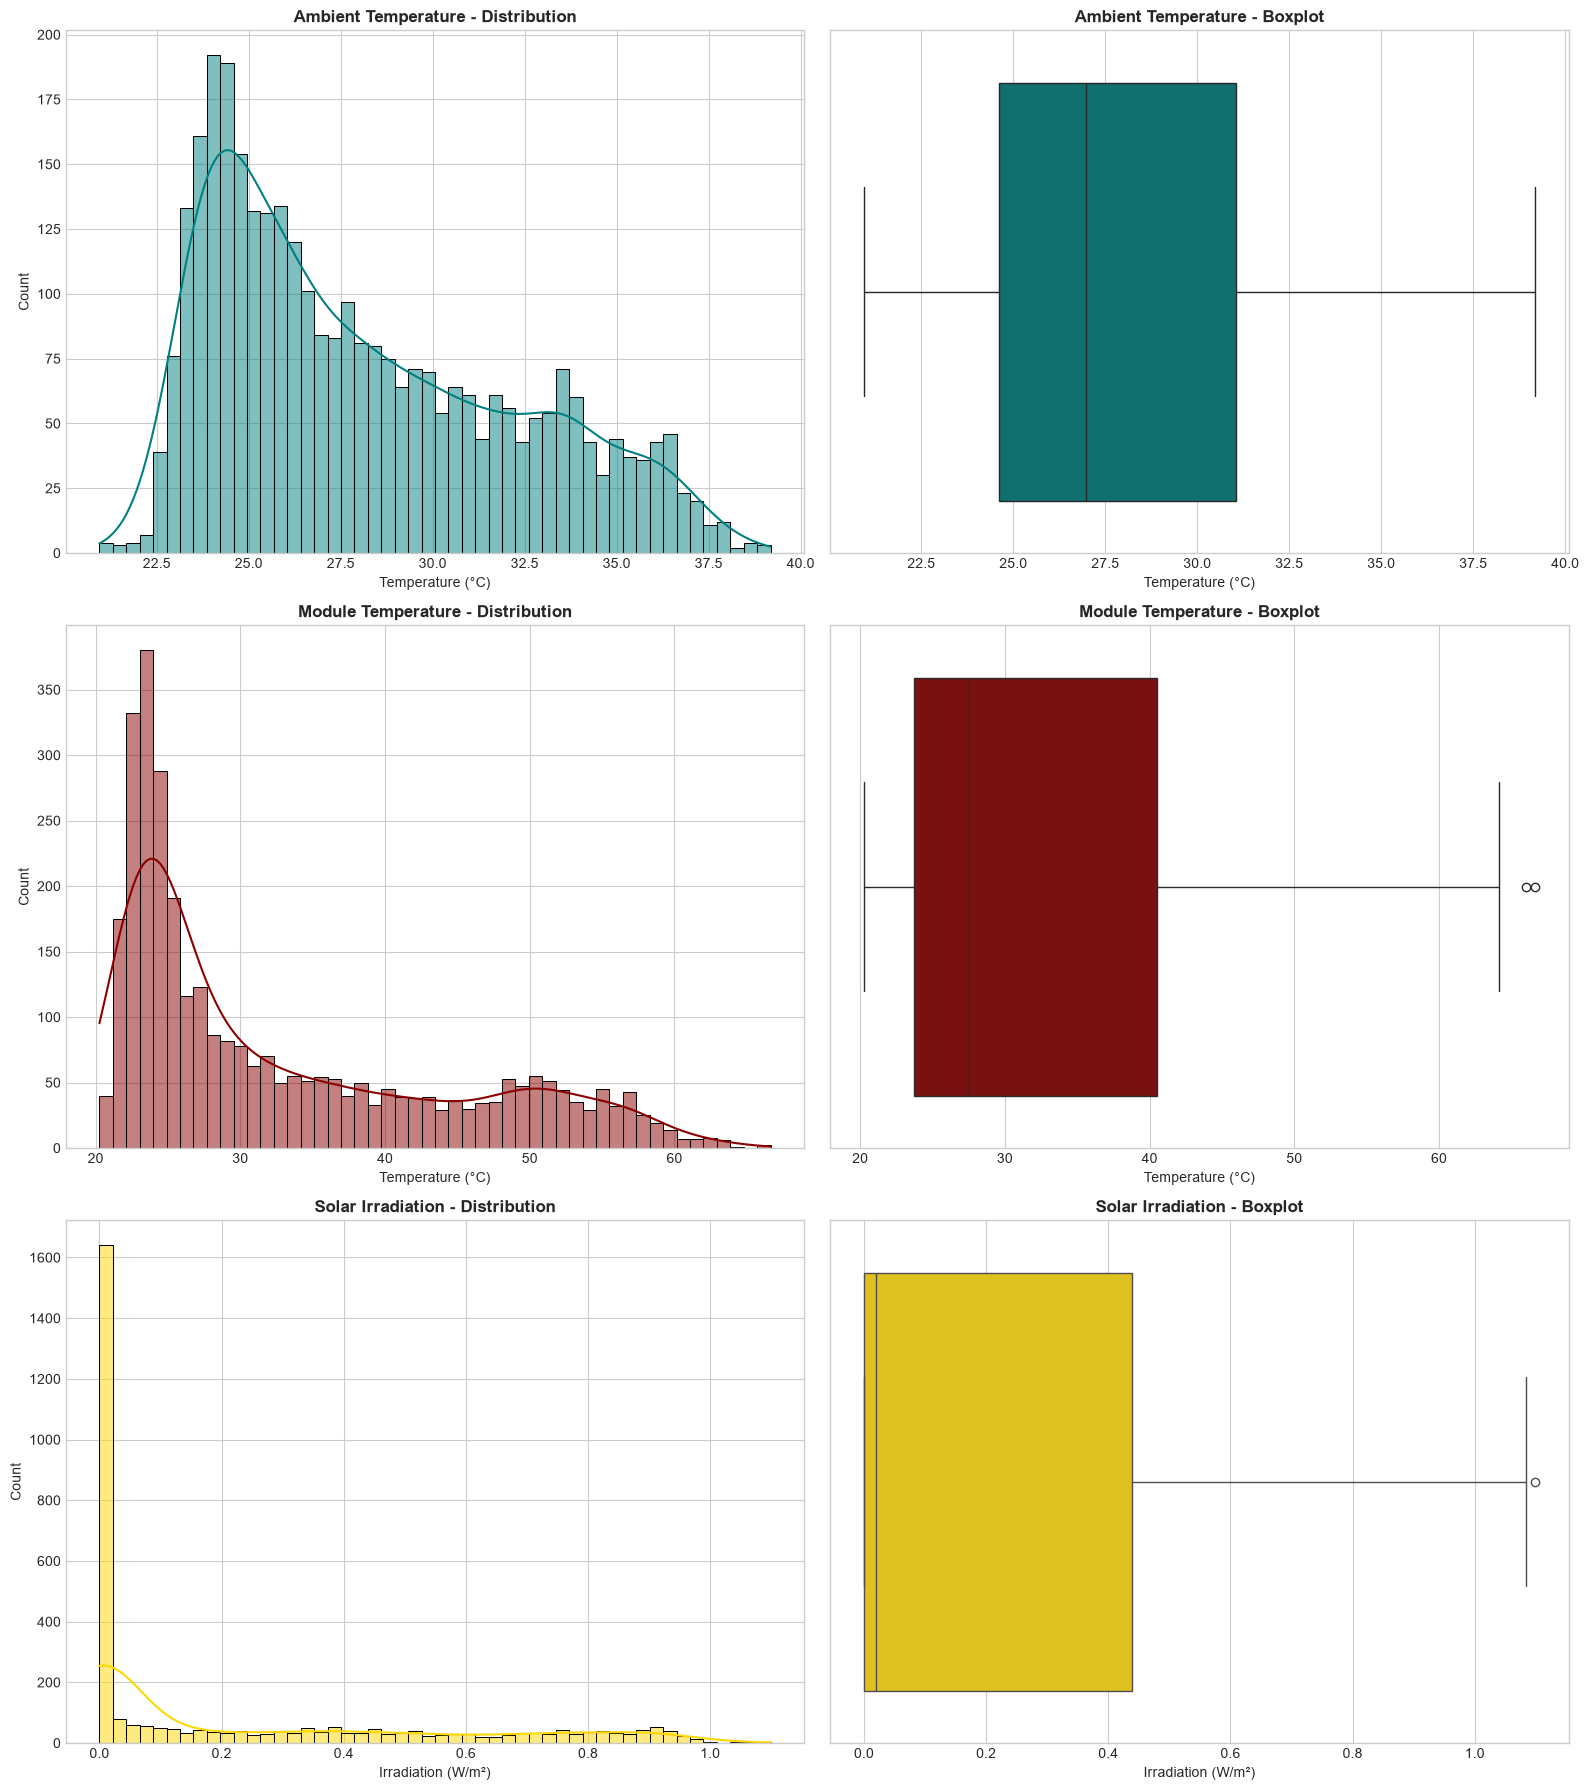

In [7]:
# Section 7: Weather feature distributions
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
colors = {'AMBIENT': 'teal', 'MODULE': 'darkred', 'IRRADIATION': 'gold'}

sns.histplot(weather_p2['AMBIENT_TEMPERATURE'], bins=50, kde=True, color=colors['AMBIENT'], ax=axes[0, 0], edgecolor='black')
axes[0, 0].set_title("Ambient Temperature - Distribution", fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel("Temperature (°C)")

sns.boxplot(x=weather_p2['AMBIENT_TEMPERATURE'], color=colors['AMBIENT'], ax=axes[0, 1])
axes[0, 1].set_title("Ambient Temperature - Boxplot", fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel("Temperature (°C)")

sns.histplot(weather_p2['MODULE_TEMPERATURE'], bins=50, kde=True, color=colors['MODULE'], ax=axes[1, 0], edgecolor='black')
axes[1, 0].set_title("Module Temperature - Distribution", fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel("Temperature (°C)")

sns.boxplot(x=weather_p2['MODULE_TEMPERATURE'], color=colors['MODULE'], ax=axes[1, 1])
axes[1, 1].set_title("Module Temperature - Boxplot", fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel("Temperature (°C)")

sns.histplot(weather_p2['IRRADIATION'], bins=50, kde=True, color=colors['IRRADIATION'], ax=axes[2, 0], edgecolor='black')
axes[2, 0].set_title("Solar Irradiation - Distribution", fontsize=12, fontweight='bold')
axes[2, 0].set_xlabel("Irradiation (W/m²)")

sns.boxplot(x=weather_p2['IRRADIATION'], color=colors['IRRADIATION'], ax=axes[2, 1])
axes[2, 1].set_title("Solar Irradiation - Boxplot", fontsize=12, fontweight='bold')
axes[2, 1].set_xlabel("Irradiation (W/m²)")

plt.tight_layout()
plt.show()


## 8. Inverter conversion efficiency over time

Compute the AC/DC power ratio (a proxy for inverter efficiency) during peak daylight hours (09:00-16:00), excluding zero-DC readings to avoid division by zero, and track it across the 34 days to spot mechanical degradation.


2026-07-05 16:59:53 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-05 16:59:53 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


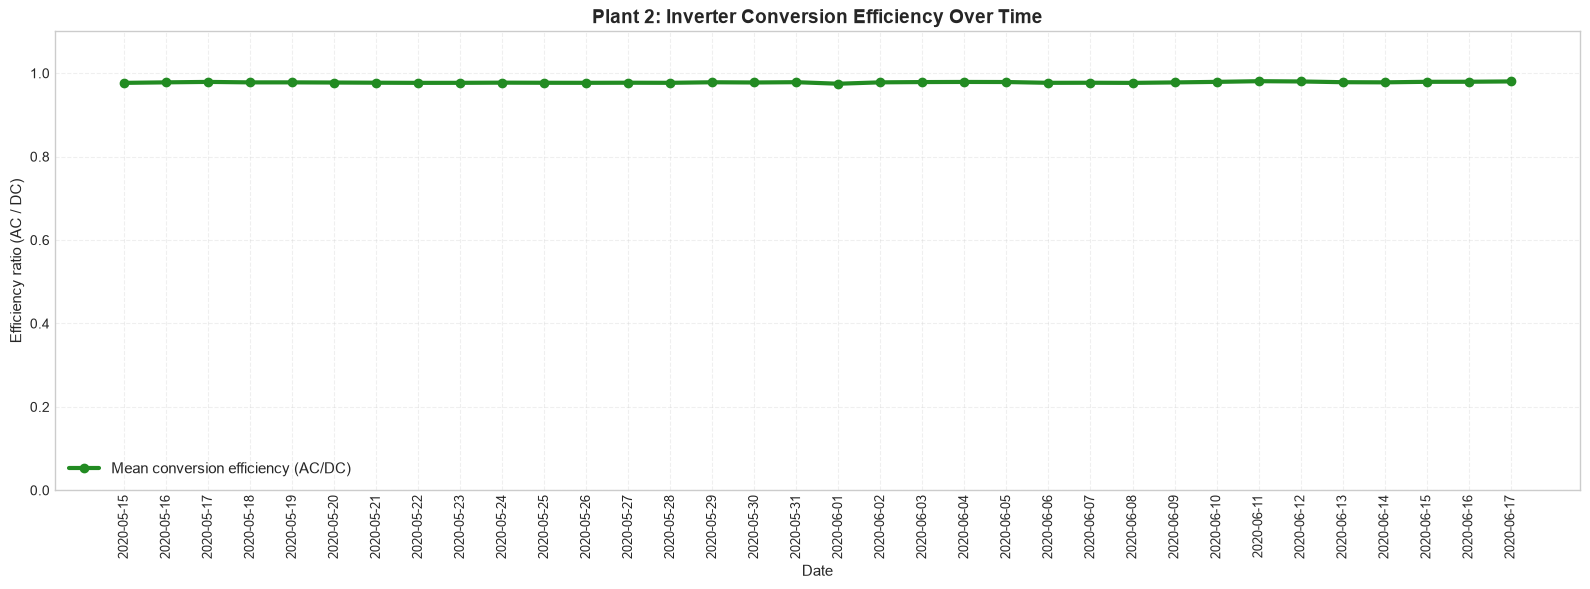

In [8]:
# Section 8: Inverter conversion efficiency over time
if 'gen_p2' not in locals():
    gen_path = '../data/raw/Plant_2_Generation_Data.csv' if os.path.exists('../data/raw/Plant_2_Generation_Data.csv') else 'Plant_2_Generation_Data.csv'
    gen_p2 = pd.read_csv(gen_path)
    gen_p2['DATE_TIME'] = pd.to_datetime(gen_p2['DATE_TIME'])
    gen_p2['DATE_STR'] = gen_p2['DATE_TIME'].dt.strftime('%Y-%m-%d')
    gen_p2['TIME_STR'] = gen_p2['DATE_TIME'].dt.strftime('%H:%M')

# Restrict to peak daylight hours and drop zero DC_POWER to avoid division by zero
daylight_df = gen_p2[(gen_p2['TIME_STR'] >= '09:00') & (gen_p2['TIME_STR'] <= '16:00')].copy()
daylight_df = daylight_df[daylight_df['DC_POWER'] > 0]

daylight_df['EFFICIENCY'] = daylight_df['AC_POWER'] / daylight_df['DC_POWER']
daily_efficiency = daylight_df.groupby('DATE_STR')['EFFICIENCY'].mean().reset_index()

plt.figure(figsize=(16, 6))
plt.plot(daily_efficiency['DATE_STR'], daily_efficiency['EFFICIENCY'],
         color='forestgreen', lw=3, marker='o', ms=6, label='Mean conversion efficiency (AC/DC)')
plt.ylim(0.0, 1.1)

x_indices = np.arange(len(daily_efficiency['DATE_STR']))
plt.gca().set_xticks(x_indices)
plt.gca().set_xticklabels(daily_efficiency['DATE_STR'], rotation=90, fontsize=9)

plt.title("Plant 2: Inverter Conversion Efficiency Over Time", fontsize=14, fontweight='bold')
plt.xlabel("Date", fontsize=11)
plt.ylabel("Efficiency ratio (AC / DC)", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='lower left', fontsize=11)
plt.tight_layout()
plt.show()


## 9. Missing value check

Count nulls (absolute and %) in both datasets before feature engineering.


In [9]:
# Section 9: Missing value check
if 'gen_p2' not in locals() or 'weather_p2' not in locals():
    gen_path = '../data/raw/Plant_2_Generation_Data.csv' if os.path.exists('../data/raw/Plant_2_Generation_Data.csv') else 'Plant_2_Generation_Data.csv'
    weather_path = '../data/raw/Plant_2_Weather_Sensor_Data.csv' if os.path.exists('../data/raw/Plant_2_Weather_Sensor_Data.csv') else 'Plant_2_Weather_Sensor_Data.csv'
    gen_p2 = pd.read_csv(gen_path)
    weather_p2 = pd.read_csv(weather_path)

gen_null_counts = gen_p2.isnull().sum()
gen_null_pcts = (gen_p2.isnull().sum() / len(gen_p2)) * 100
gen_null_table = pd.DataFrame({
    'feature': gen_null_counts.index,
    'null_count': gen_null_counts.values,
    'null_pct': gen_null_pcts.values
})

print("Generation data — missing values:")
print(gen_null_table.to_string(index=False, formatters={'null_pct': '{:.4f}%'.format}))
print(f"Total rows: {len(gen_p2):,}\n")

weather_null_counts = weather_p2.isnull().sum()
weather_null_pcts = (weather_p2.isnull().sum() / len(weather_p2)) * 100
weather_null_table = pd.DataFrame({
    'feature': weather_null_counts.index,
    'null_count': weather_null_counts.values,
    'null_pct': weather_null_pcts.values
})

print("Weather data — missing values:")
print(weather_null_table.to_string(index=False, formatters={'null_pct': '{:.4f}%'.format}))
print(f"Total rows: {len(weather_p2):,}")


Generation data — missing values:
    feature  null_count null_pct
  DATE_TIME           0  0.0000%
   PLANT_ID           0  0.0000%
 SOURCE_KEY           0  0.0000%
   DC_POWER           0  0.0000%
   AC_POWER           0  0.0000%
DAILY_YIELD           0  0.0000%
TOTAL_YIELD           0  0.0000%
   DATE_STR           0  0.0000%
   TIME_STR           0  0.0000%
Total rows: 67,698

Weather data — missing values:
            feature  null_count null_pct
          DATE_TIME           0  0.0000%
           PLANT_ID           0  0.0000%
         SOURCE_KEY           0  0.0000%
AMBIENT_TEMPERATURE           0  0.0000%
 MODULE_TEMPERATURE           0  0.0000%
        IRRADIATION           0  0.0000%
Total rows: 3,259


## 10. Data quality issue: DAILY_YIELD doesn't reset at midnight

Unlike Plant 1, some Plant 2 inverters' `DAILY_YIELD` counter doesn't reset to 0 at midnight — it carries over yesterday's value. This means `DAILY_YIELD` can't be used directly as a model feature or target for Plant 2 without correcting for this.


In [10]:
# Section 10: Checking DAILY_YIELD at midnight
if 'gen_p2' not in locals():
    gen_path = '../data/raw/Plant_2_Generation_Data.csv' if os.path.exists('../data/raw/Plant_2_Generation_Data.csv') else 'Plant_2_Generation_Data.csv'
    gen_p2 = pd.read_csv(gen_path)
    gen_p2['DATE_TIME'] = pd.to_datetime(gen_p2['DATE_TIME'])
    gen_p2['DATE_STR'] = gen_p2['DATE_TIME'].dt.strftime('%Y-%m-%d')
    gen_p2['TIME_STR'] = gen_p2['DATE_TIME'].dt.strftime('%H:%M')

midnight_df = gen_p2[gen_p2['TIME_STR'] == '00:00'].sort_values(['DATE_STR', 'SOURCE_KEY'])

print("DAILY_YIELD at 00:00 - should be close to 0, but some inverters carry over thousands of kWh:")
print(midnight_df[['DATE_STR', 'SOURCE_KEY', 'DAILY_YIELD']].head(6).to_string(index=False))


DAILY_YIELD at 00:00 - should be close to 0, but some inverters carry over thousands of kWh:
  DATE_STR      SOURCE_KEY  DAILY_YIELD
2020-05-15 4UPUqMRk7TRMgml  9425.000000
2020-05-15 81aHJ1q11NBPMrL     0.000000
2020-05-15 9kRcWv60rDACzjR  3075.333333
2020-05-15 Et9kgGMDl729KT4   269.933333
2020-05-15 IQ2d7wF4YD8zU1Q  3177.000000
2020-05-15 LYwnQax7tkwH5Cb  1872.500000


## 11. DC power spread across inverters at peak hours

Boxplot of DC power for each inverter between 11:00-13:00, to check for underperforming units.


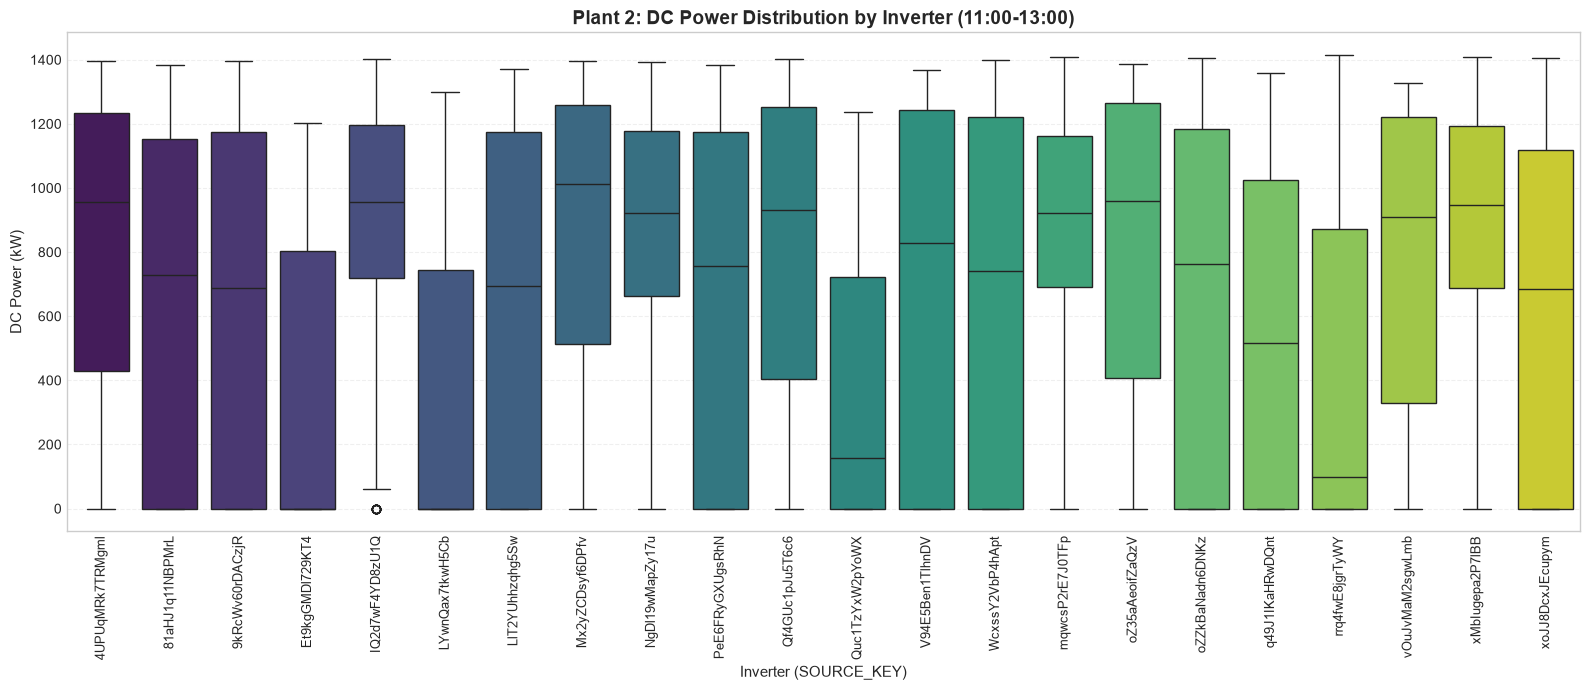

In [11]:
# Section 11: DC power spread across inverters at peak hours
peak_daylight = gen_p2[(gen_p2['TIME_STR'] >= '11:00') & (gen_p2['TIME_STR'] <= '13:00')]

plt.figure(figsize=(16, 7))
sns.boxplot(
    data=peak_daylight.sort_values('SOURCE_KEY'),
    x='SOURCE_KEY', y='DC_POWER', hue='SOURCE_KEY', palette='viridis', legend=False
)

plt.xticks(rotation=90, fontsize=9)
plt.title("Plant 2: DC Power Distribution by Inverter (11:00-13:00)", fontsize=14, fontweight='bold')
plt.xlabel("Inverter (SOURCE_KEY)", fontsize=11)
plt.ylabel("DC Power (kW)", fontsize=11)
plt.grid(True, axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


## 12. Module temperature per day (small multiples)

Same small-multiples check as Plant 1, for module temperature.


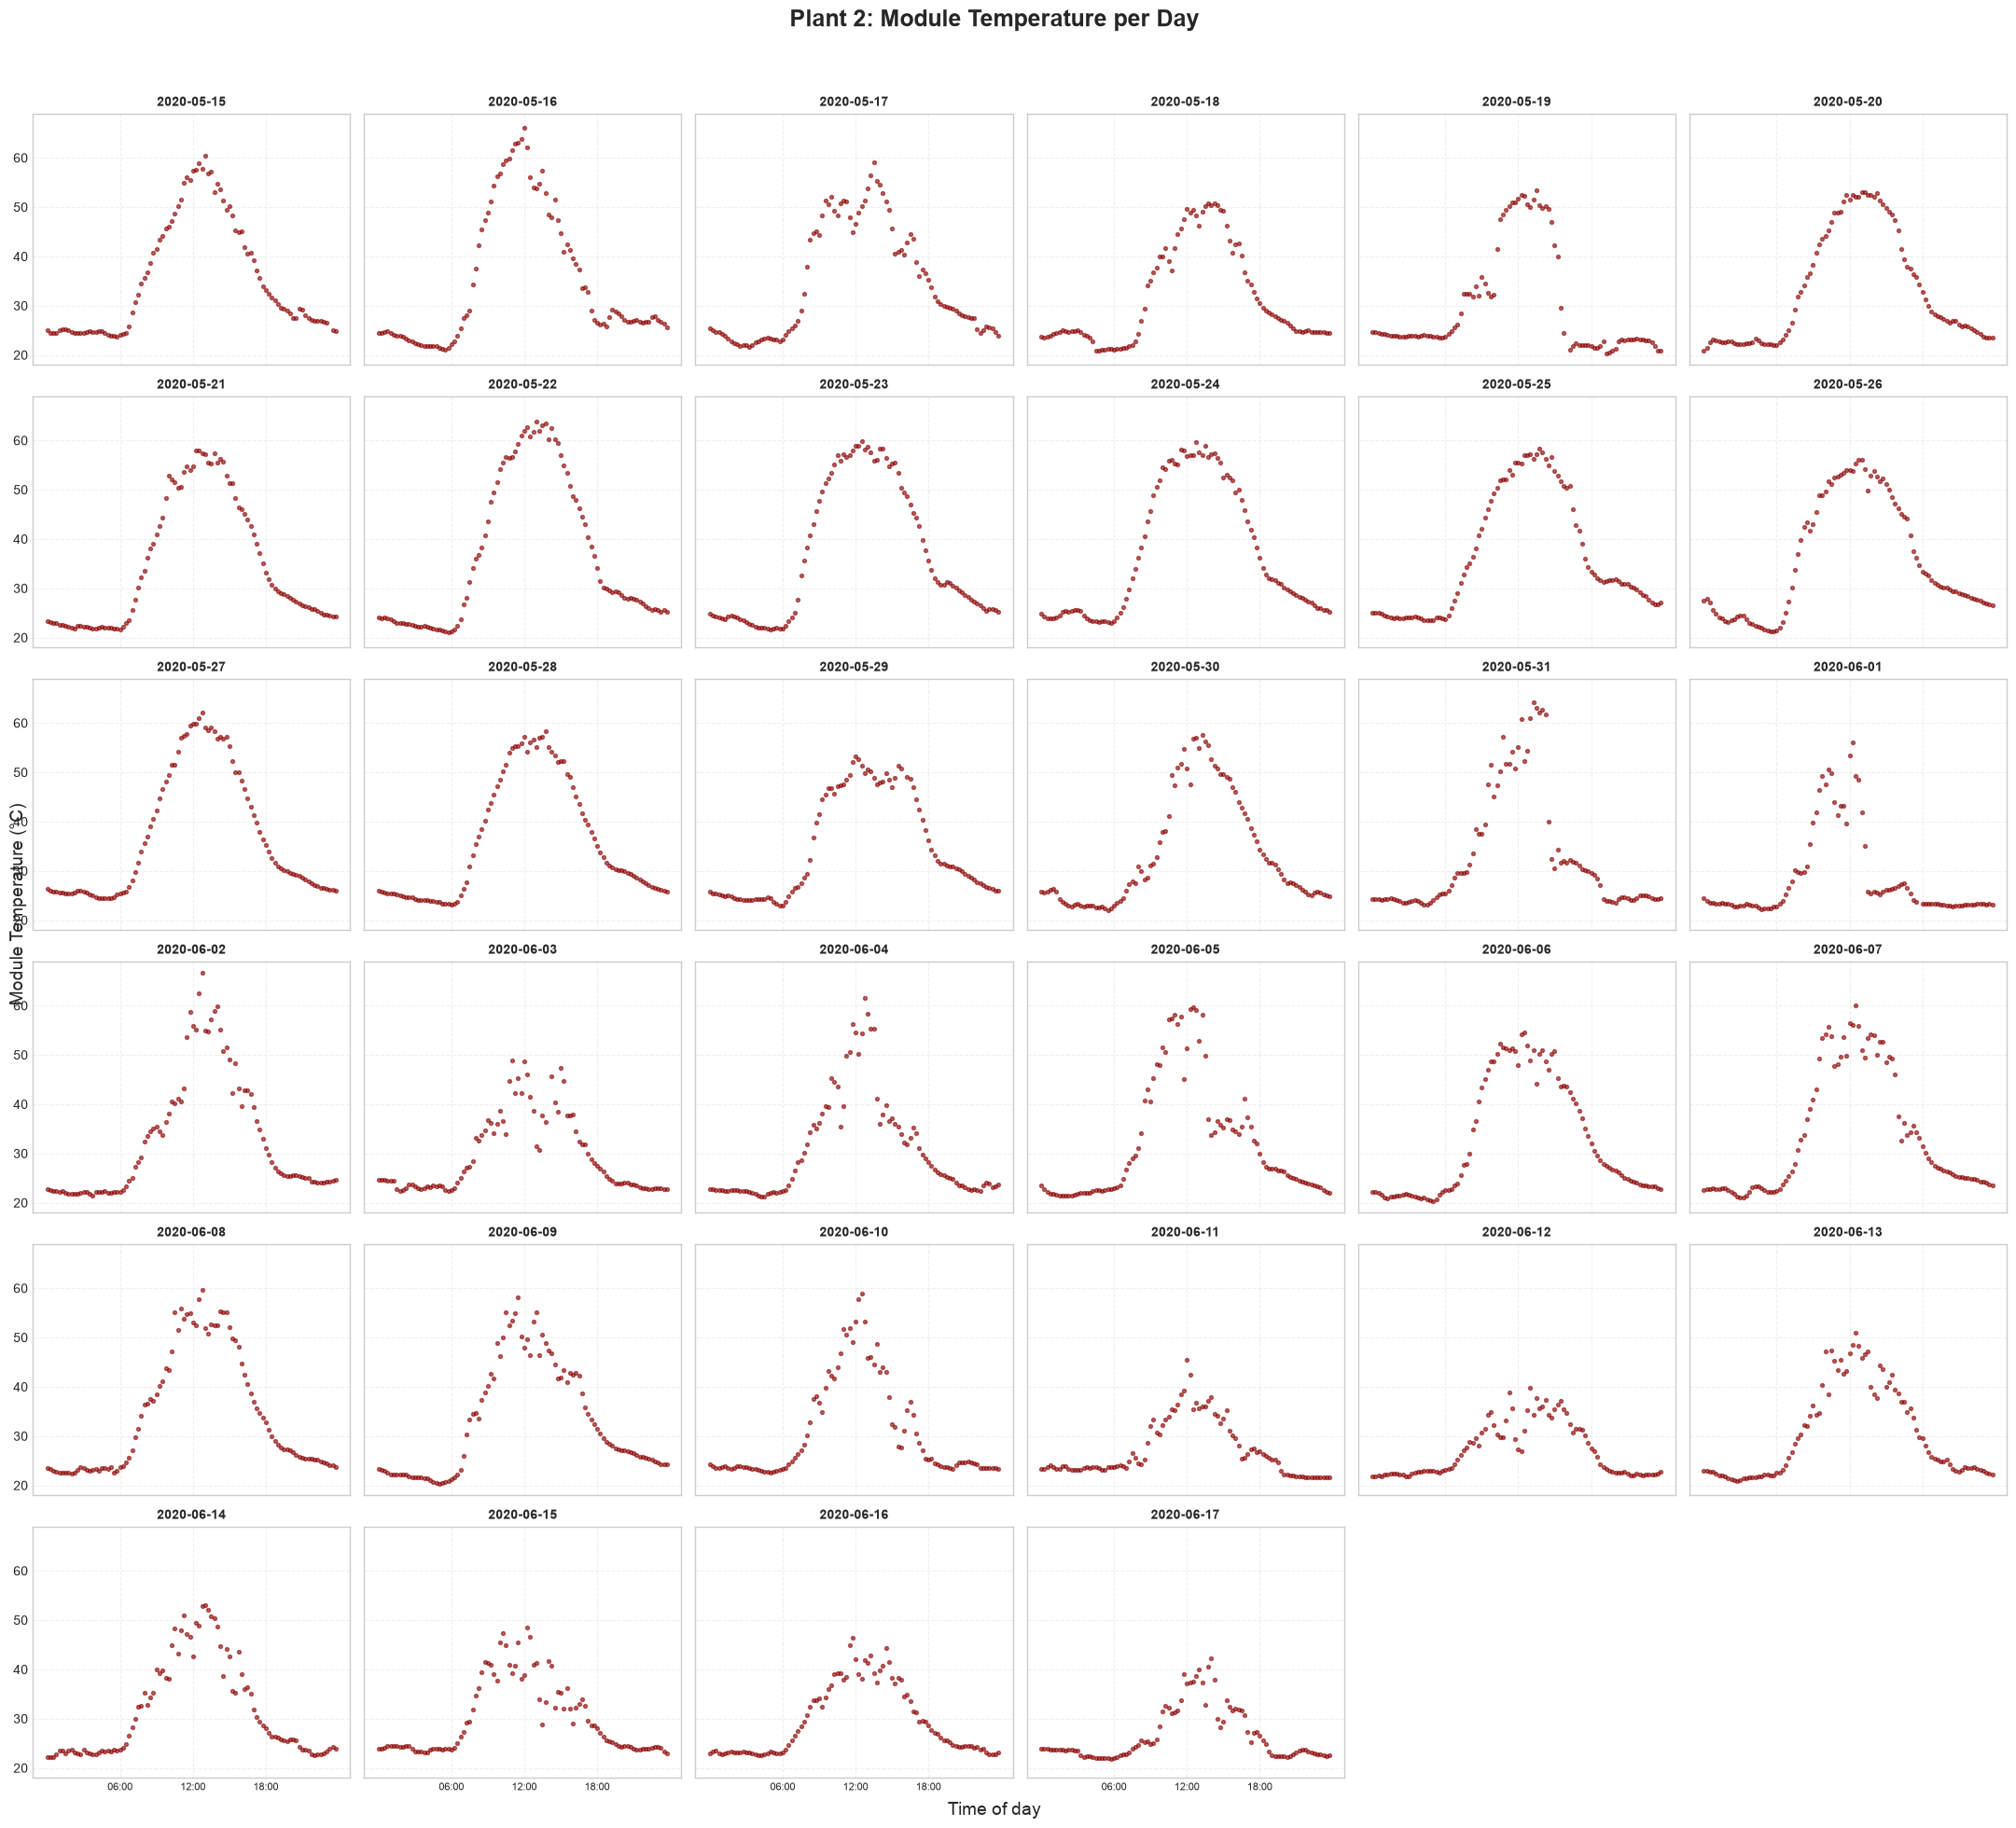

In [12]:
# Section 12: Module temperature per day, small multiples
if 'weather_p2' not in locals():
    weather_path = '../data/raw/Plant_2_Weather_Sensor_Data.csv' if os.path.exists('../data/raw/Plant_2_Weather_Sensor_Data.csv') else 'Plant_2_Weather_Sensor_Data.csv'
    weather_p2 = pd.read_csv(weather_path)
    weather_p2['DATE_TIME'] = pd.to_datetime(weather_p2['DATE_TIME'])

df_mod = weather_p2.copy()
df_mod['DATE_STR'] = df_mod['DATE_TIME'].dt.strftime('%Y-%m-%d')
df_mod['TIME_MINUTES'] = df_mod['DATE_TIME'].dt.hour * 60 + df_mod['DATE_TIME'].dt.minute

unique_days = sorted(df_mod['DATE_STR'].unique())

fig, axes = plt.subplots(6, 6, figsize=(22, 20), sharex=True, sharey=True)
axes_flat = axes.flatten()

for i, day in enumerate(unique_days):
    day_data = df_mod[df_mod['DATE_STR'] == day]
    ax = axes_flat[i]
    ax.scatter(day_data['TIME_MINUTES'], day_data['MODULE_TEMPERATURE'], color='darkred', alpha=0.6, s=8)
    ax.set_title(day, fontsize=10, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.set_xticks([360, 720, 1080])
    ax.set_xticklabels(['06:00', '12:00', '18:00'], fontsize=8)

for j in range(len(unique_days), len(axes_flat)):
    fig.delaxes(axes_flat[j])

fig.suptitle("Plant 2: Module Temperature per Day", fontsize=18, fontweight='bold', y=0.98)
fig.supxlabel("Time of day", fontsize=14)
fig.supylabel("Module Temperature (°C)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


## 13. Ambient temperature per day (small multiples)

Same view as Section 12, for ambient air temperature, to compare against module temperature.


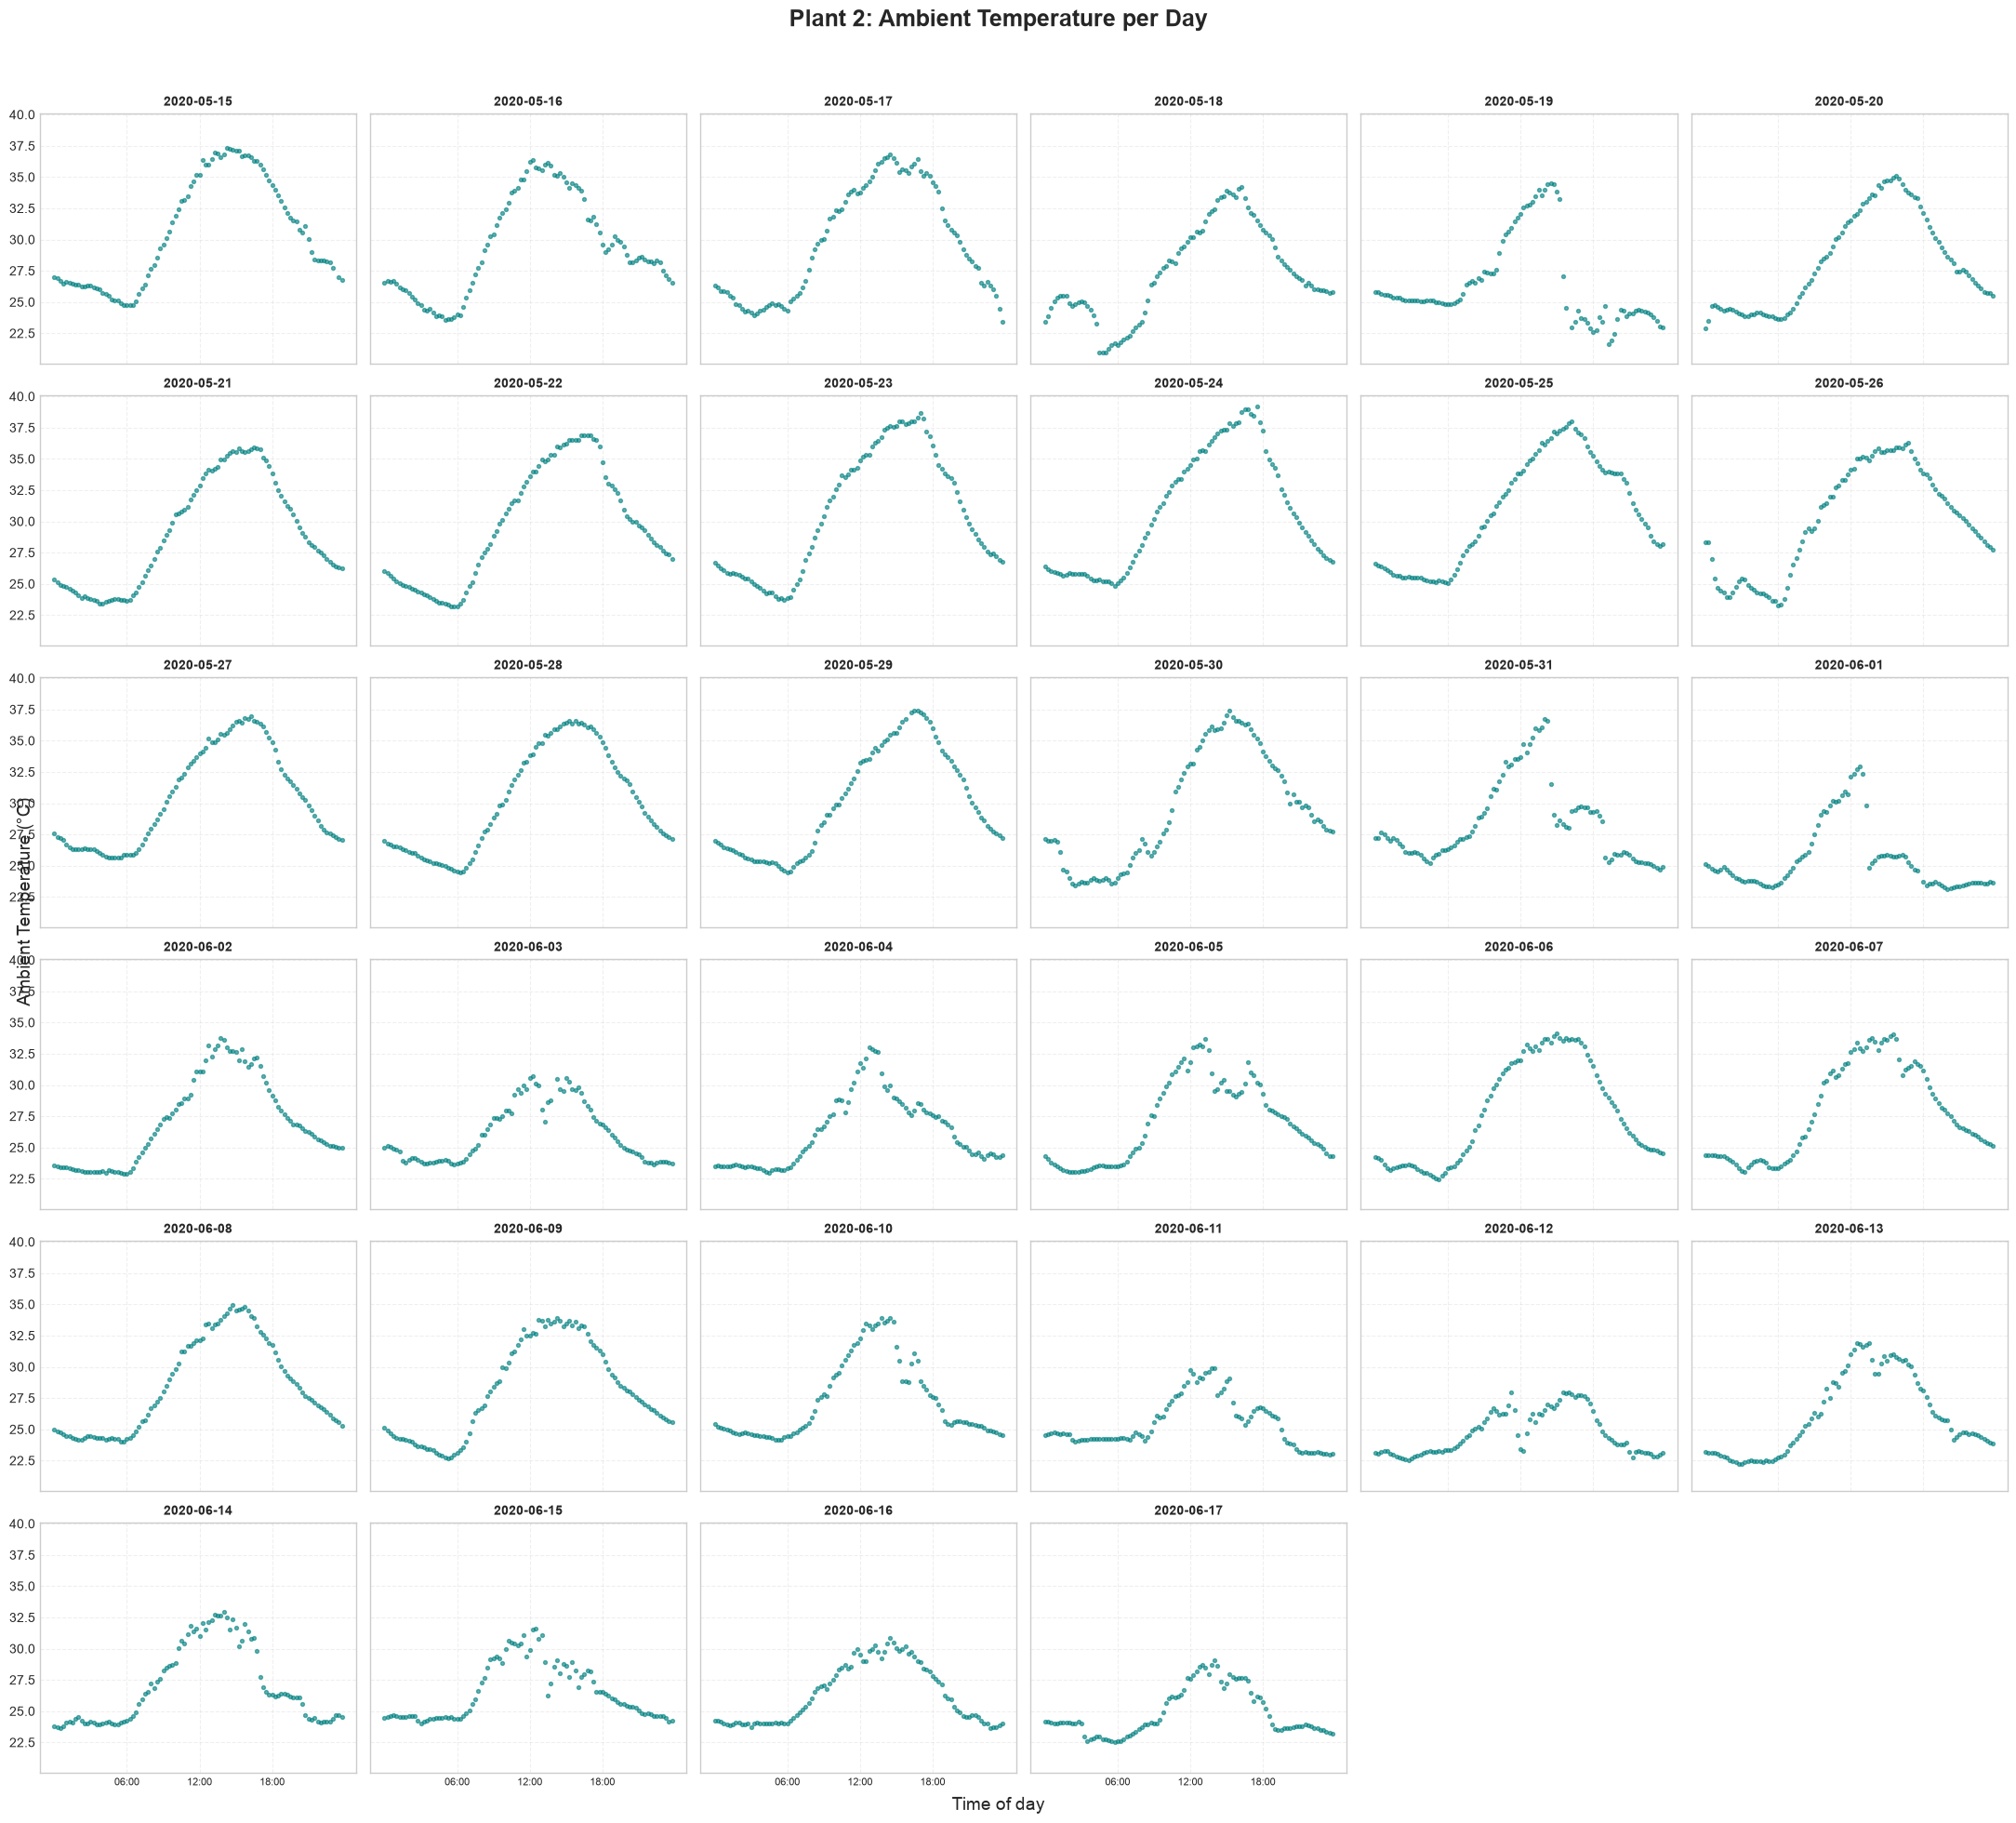

In [13]:
# Section 13: Ambient temperature per day, small multiples
if 'weather_p2' not in locals():
    weather_path = '../data/raw/Plant_2_Weather_Sensor_Data.csv' if os.path.exists('../data/raw/Plant_2_Weather_Sensor_Data.csv') else 'Plant_2_Weather_Sensor_Data.csv'
    weather_p2 = pd.read_csv(weather_path)
    weather_p2['DATE_TIME'] = pd.to_datetime(weather_p2['DATE_TIME'])

df_amb = weather_p2.copy()
df_amb['DATE_STR'] = df_amb['DATE_TIME'].dt.strftime('%Y-%m-%d')
df_amb['TIME_MINUTES'] = df_amb['DATE_TIME'].dt.hour * 60 + df_amb['DATE_TIME'].dt.minute

unique_days = sorted(df_amb['DATE_STR'].unique())

fig, axes = plt.subplots(6, 6, figsize=(22, 20), sharex=True, sharey=True)
axes_flat = axes.flatten()

for i, day in enumerate(unique_days):
    day_data = df_amb[df_amb['DATE_STR'] == day]
    ax = axes_flat[i]
    ax.scatter(day_data['TIME_MINUTES'], day_data['AMBIENT_TEMPERATURE'], color='teal', alpha=0.6, s=8)
    ax.set_title(day, fontsize=10, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.set_xticks([360, 720, 1080])
    ax.set_xticklabels(['06:00', '12:00', '18:00'], fontsize=8)

for j in range(len(unique_days), len(axes_flat)):
    fig.delaxes(axes_flat[j])

fig.suptitle("Plant 2: Ambient Temperature per Day", fontsize=18, fontweight='bold', y=0.98)
fig.supxlabel("Time of day", fontsize=14)
fig.supylabel("Ambient Temperature (°C)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


## 14. Confirming the midnight reset bug with a direct comparison

Compare a healthy inverter (resets to 0 kWh at midnight) against two inverters that carry over thousands of kWh from the previous day, on `2020-05-15` at 00:00.


In [14]:
# Section 14: Confirming the midnight reset bug
if 'gen_p2' not in locals():
    gen_path = '../data/raw/Plant_2_Generation_Data.csv' if os.path.exists('../data/raw/Plant_2_Generation_Data.csv') else 'Plant_2_Generation_Data.csv'
    gen_p2 = pd.read_csv(gen_path)
    gen_p2['DATE_TIME'] = pd.to_datetime(gen_p2['DATE_TIME'])
    gen_p2['DATE_STR'] = gen_p2['DATE_TIME'].dt.strftime('%Y-%m-%d')
    gen_p2['TIME_STR'] = gen_p2['DATE_TIME'].dt.strftime('%H:%M')

target_test_date = '2020-05-15'
midnight_flashpoint = gen_p2[
    (gen_p2['DATE_STR'] == target_test_date) &
    (gen_p2['TIME_STR'] == '00:00')
].sort_values('SOURCE_KEY')

print(f"DAILY_YIELD at {target_test_date} 00:00 - some inverters carry over yesterday's value instead of resetting to 0:")
print(midnight_flashpoint[['DATE_STR', 'TIME_STR', 'SOURCE_KEY', 'DAILY_YIELD']].to_string(index=False, formatters={'DAILY_YIELD': '{:,.2f}'.format}))


DAILY_YIELD at 2020-05-15 00:00 - some inverters carry over yesterday's value instead of resetting to 0:
  DATE_STR TIME_STR      SOURCE_KEY DAILY_YIELD
2020-05-15    00:00 4UPUqMRk7TRMgml    9,425.00
2020-05-15    00:00 81aHJ1q11NBPMrL        0.00
2020-05-15    00:00 9kRcWv60rDACzjR    3,075.33
2020-05-15    00:00 Et9kgGMDl729KT4      269.93
2020-05-15    00:00 IQ2d7wF4YD8zU1Q    3,177.00
2020-05-15    00:00 LYwnQax7tkwH5Cb    1,872.50
2020-05-15    00:00 LlT2YUhhzqhg5Sw    1,094.36
2020-05-15    00:00 Mx2yZCDsyf6DPfv    5,692.20
2020-05-15    00:00 NgDl19wMapZy17u    1,866.20
2020-05-15    00:00 PeE6FRyGXUgsRhN      651.20
2020-05-15    00:00 Qf4GUc1pJu5T6c6        0.00
2020-05-15    00:00 Quc1TzYxW2pYoWX    5,495.00
2020-05-15    00:00 V94E5Ben1TlhnDV        0.00
2020-05-15    00:00 WcxssY2VbP4hApt        0.00
2020-05-15    00:00 mqwcsP2rE7J0TFp    1,238.53
2020-05-15    00:00 oZ35aAeoifZaQzV    1,281.47
2020-05-15    00:00 oZZkBaNadn6DNKz        0.00
2020-05-15    00:00 q49J1IKaHRw

## 15. Visualizing the reset bug over a full day

Plot `DAILY_YIELD` across a full 24-hour cycle for one healthy inverter and two buggy ones, to see how the bug creates an offset that stays roughly constant throughout the day.


2026-07-05 16:59:55 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-05 16:59:55 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-05 16:59:55 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-05 16:59:55 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-05 16:59:55 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-05 16:59:55 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


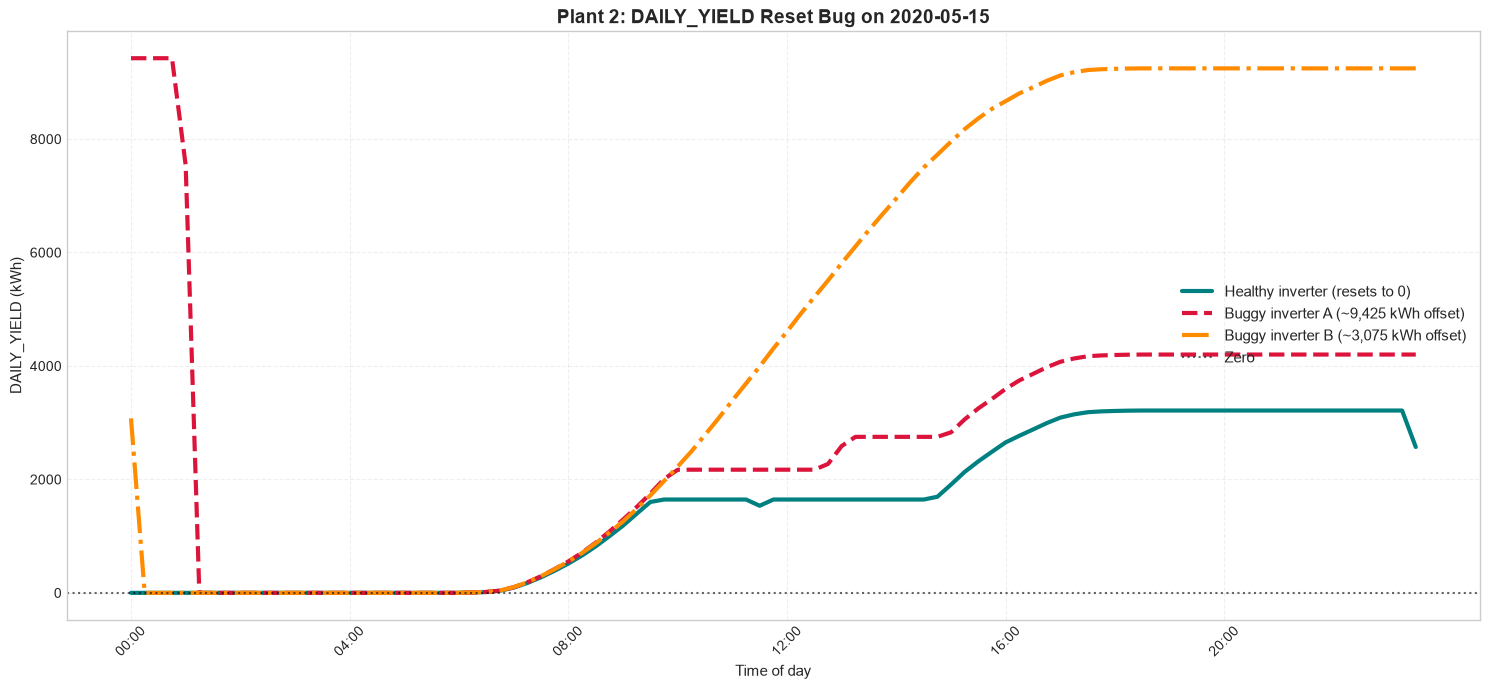

In [15]:
# Section 15: Visualizing the reset bug over a full day
plt.figure(figsize=(15, 7))

target_inverters = {
    '81aHJ1q11NBPMrL': {'label': 'Healthy inverter (resets to 0)', 'color': 'teal', 'ls': '-'},
    '4UPUqMRk7TRMgml': {'label': 'Buggy inverter A (~9,425 kWh offset)', 'color': 'crimson', 'ls': '--'},
    '9kRcWv60rDACzjR': {'label': 'Buggy inverter B (~3,075 kWh offset)', 'color': 'darkorange', 'ls': '-.'}
}

for key, meta in target_inverters.items():
    single_asset_day = gen_p2[
        (gen_p2['SOURCE_KEY'] == key) &
        (gen_p2['DATE_STR'] == target_test_date)
    ].sort_values('DATE_TIME')

    plt.plot(single_asset_day['TIME_STR'], single_asset_day['DAILY_YIELD'],
             color=meta['color'], linestyle=meta['ls'], lw=3, label=meta['label'])

# Show a tick every 4 hours
ax = plt.gca()
target_indices = np.arange(0, len(single_asset_day['TIME_STR']), 16)
ax.set_xticks(target_indices)
ax.set_xticklabels(single_asset_day['TIME_STR'].iloc[target_indices], rotation=45)

plt.axhline(0, color='black', lw=1.5, linestyle=':', alpha=0.6, label='Zero')

plt.title(f"Plant 2: DAILY_YIELD Reset Bug on {target_test_date}", fontsize=14, fontweight='bold')
plt.xlabel("Time of day", fontsize=11)
plt.ylabel("DAILY_YIELD (kWh)", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='center right', fontsize=11)
plt.tight_layout()
plt.show()


# 16. Data preparation

Given the `DAILY_YIELD`/`TOTAL_YIELD` reset bug found above, the feature set excludes those columns entirely and instead:
1. Takes the median `DC_POWER`/`AC_POWER` across all 22 inverters per timestamp (smooths out individual dropouts).
2. Inner-joins with weather data on `DATE_TIME`.
3. Keeps only `DC_POWER`, `AC_POWER`, and the three weather features.


In [16]:
# Section 16: Data preparation
logger.info("Preparing Plant 2 features.")

gen_path = '../data/raw/Plant_2_Generation_Data.csv' if os.path.exists('../data/raw/Plant_2_Generation_Data.csv') else 'Plant_2_Generation_Data.csv'
weather_path = '../data/raw/Plant_2_Weather_Sensor_Data.csv' if os.path.exists('../data/raw/Plant_2_Weather_Sensor_Data.csv') else 'Plant_2_Weather_Sensor_Data.csv'

gen_raw = pd.read_csv(gen_path)
weather_raw = pd.read_csv(weather_path)

gen_raw['DATE_TIME'] = pd.to_datetime(gen_raw['DATE_TIME'])
weather_raw['DATE_TIME'] = pd.to_datetime(weather_raw['DATE_TIME'])

# Median across inverters smooths out individual dropouts
gen_cleansed = gen_raw.groupby('DATE_TIME')[['DC_POWER', 'AC_POWER']].median().reset_index()

# DAILY_YIELD / TOTAL_YIELD are excluded due to the midnight reset bug found above
plant2_master = pd.merge(gen_cleansed, weather_raw, on='DATE_TIME', how='inner')
target_features = ['DATE_TIME', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION', 'DC_POWER', 'AC_POWER']
plant2_master = plant2_master[target_features]

output_path = '../data/processed/plant2_master_features.csv'
output_dir = os.path.dirname(output_path) if output_path.startswith('..') else '.'
if output_dir and output_dir != '.' and not os.path.exists(output_dir):
    os.makedirs(output_dir)

plant2_master.to_csv(output_path, index=False)
logger.info(f"Saved features to {output_path}")

print(f"Rows: {plant2_master.shape[0]:,}")
print(f"Columns: {list(plant2_master.columns)}")
print(f"Remaining nulls: {plant2_master.isnull().sum().sum()}")


2026-07-05 16:59:55 [INFO] Preparing Plant 2 features.


2026-07-05 16:59:55 [INFO] Saved features to ../data/processed/plant2_master_features.csv


Rows: 3,259
Columns: ['DATE_TIME', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION', 'DC_POWER', 'AC_POWER']
Remaining nulls: 0


# 17. Train/test split and model training

Same approach as Plant 1: train a LightGBM regressor on the three weather features to predict `DC_POWER`, using a chronological split (train: 05/15-06/11, test: 06/12-06/17) to avoid leakage.


In [17]:
# Section 17: Train/test split and model training
processed_path = '../data/processed/plant2_master_features.csv' if os.path.exists('../data/processed/plant2_master_features.csv') else 'plant2_master_features.csv'
df_master = pd.read_csv(processed_path)
df_master['DATE_TIME'] = pd.to_datetime(df_master['DATE_TIME'])
df_master['DATE_STR'] = df_master['DATE_TIME'].dt.strftime('%Y-%m-%d')

features = ['AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']
X = df_master[features]
y = df_master['DC_POWER']
dates = df_master['DATE_STR']

train_mask = dates <= '2020-06-11'
test_mask = (dates >= '2020-06-12') & (dates <= '2020-06-17')

X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[test_mask], y[test_mask]

print(f"Train rows (05/15-06/11): {X_train.shape[0]:,}")
print(f"Test rows  (06/12-06/17): {X_test.shape[0]:,}")

logger.info("Training LightGBM model.")
model = lgb.LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

rmse_eval = np.sqrt(mean_squared_error(y_test, y_pred))
r2_eval = r2_score(y_test, y_pred)

print(f"\nTest RMSE: {rmse_eval:.4f} kW")
print(f"Test R2:   {r2_eval:.4f} ({r2_eval*100:.2f}%)")


2026-07-05 16:59:55 [INFO] Training LightGBM model.


Train rows (05/15-06/11): 2,683
Test rows  (06/12-06/17): 576



Test RMSE: 106.6878 kW
Test R2:   0.8819 (88.19%)


## 18. Feature importance

Check that the model relies most heavily on irradiation and module temperature, matching physical intuition.


2026-07-05 16:59:56 [INFO] Plotting feature importance.


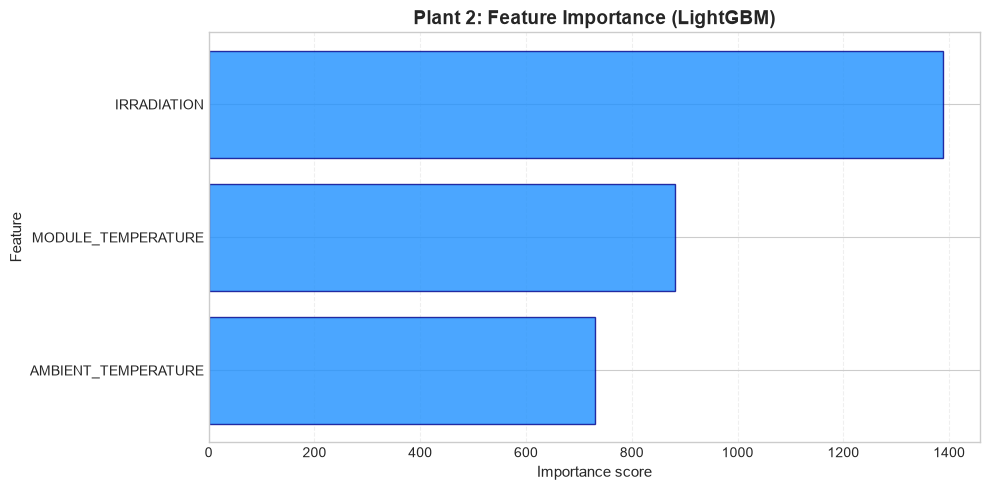

In [18]:
# Section 18: Feature importance
logger.info("Plotting feature importance.")

importance_values = model.feature_importances_
feature_names = X.columns

importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importance_values}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='dodgerblue', edgecolor='darkblue', alpha=0.8)

plt.title("Plant 2: Feature Importance (LightGBM)", fontsize=14, fontweight='bold')
plt.xlabel("Importance score", fontsize=11)
plt.ylabel("Feature", fontsize=11)
plt.grid(True, axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


## 19. Converting predictions to daily energy (kWh)

Since `DAILY_YIELD`/`TOTAL_YIELD` aren't usable for Plant 2 (Section 10), the AC/DC conversion ratio is instead estimated empirically from the training data (rather than assuming a fixed 92% as in Plant 1), then applied to convert predicted DC power into AC energy and integrate over 15-minute intervals into daily kWh totals.


2026-07-05 16:59:56 [INFO] Converting predictions to daily energy.


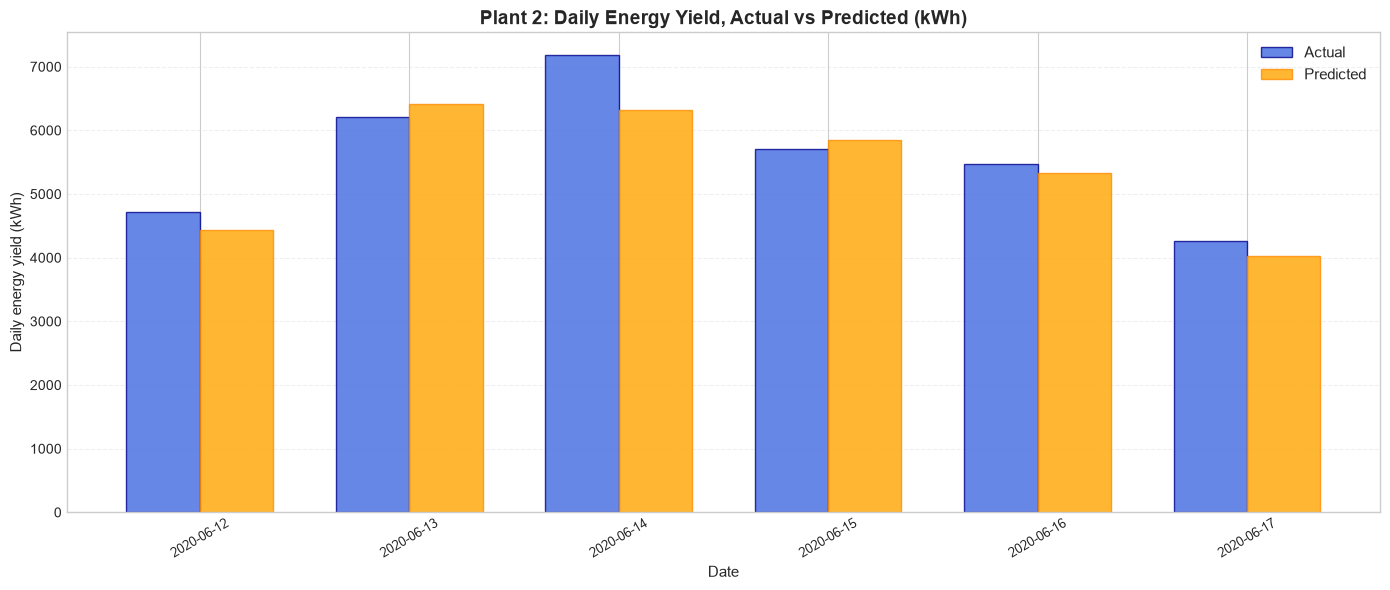

2026-07-05 16:59:56 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-05 16:59:56 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-05 16:59:56 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-05 16:59:56 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


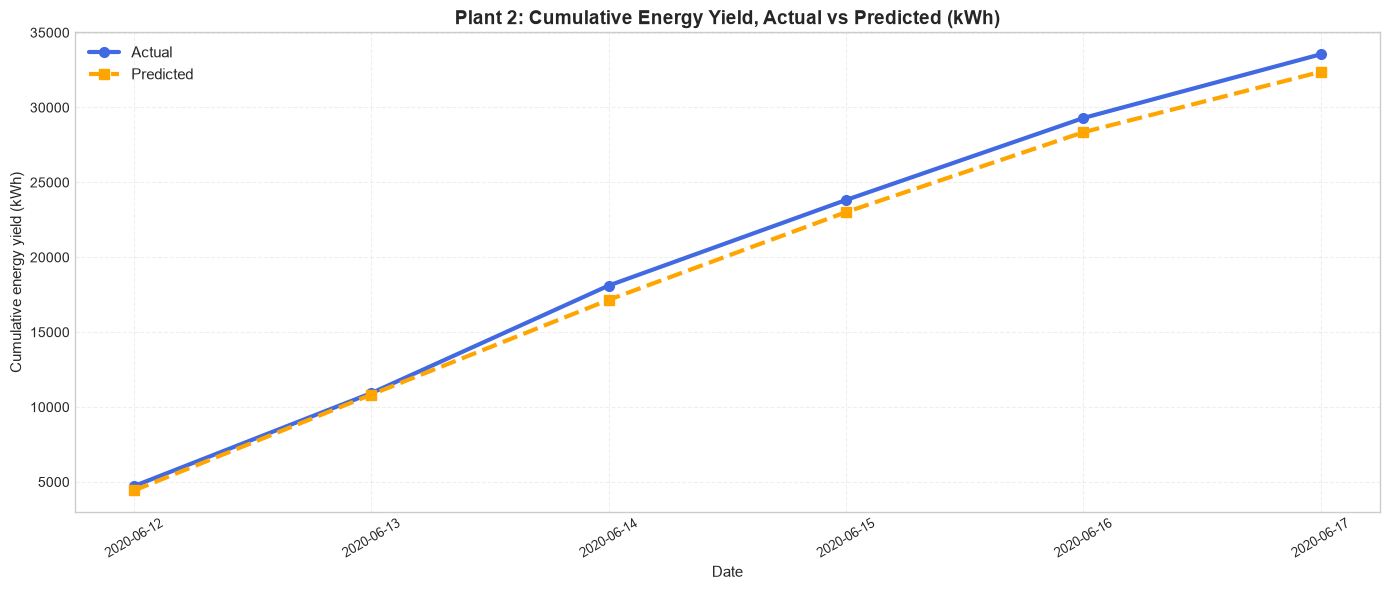

In [19]:
# Section 19: Converting predictions to daily energy (kWh)
logger.info("Converting predictions to daily energy.")

if 'model' not in locals() or 'X_test' not in locals():
    raise NameError("Run the model training cell (Section 17) first.")

y_pred_dc = model.predict(X_test)

validation_df = pd.DataFrame({
    'DATE_TIME': df_master.loc[test_mask, 'DATE_TIME'],
    'DATE_STR': df_master.loc[test_mask, 'DATE_STR'],
    'DC_ACTUAL': y_test.values,
    'DC_PREDICTED': y_pred_dc,
    'AC_ACTUAL': df_master.loc[test_mask, 'AC_POWER'].values
})

# Estimate the AC/DC conversion ratio from the training data
train_clean = df_master[train_mask]
conversion_ratio = (train_clean['AC_POWER'] / train_clean['DC_POWER']).replace([np.inf, -np.inf], np.nan).dropna().mean()
validation_df['AC_PREDICTED'] = validation_df['DC_PREDICTED'] * conversion_ratio

# 15-minute intervals = 0.25 hours
validation_df['YIELD_ACTUAL_15MIN'] = validation_df['AC_ACTUAL'] * (15.0 / 60.0)
validation_df['YIELD_PRED_15MIN'] = validation_df['AC_PREDICTED'] * (15.0 / 60.0)

daily_yield_summary = validation_df.groupby('DATE_STR').agg({
    'YIELD_ACTUAL_15MIN': 'sum',
    'YIELD_PRED_15MIN': 'sum'
}).reset_index()
daily_yield_summary.columns = ['DATE_STR', 'DAILY_YIELD_ACTUAL', 'DAILY_YIELD_PREDICTED']

daily_yield_summary['TOTAL_YIELD_ACTUAL'] = daily_yield_summary['DAILY_YIELD_ACTUAL'].cumsum()
daily_yield_summary['TOTAL_YIELD_PREDICTED'] = daily_yield_summary['DAILY_YIELD_PREDICTED'].cumsum()

# Chart 1: daily yield, actual vs predicted
plt.figure(figsize=(14, 6))
x_indices = np.arange(len(daily_yield_summary))
bar_width = 0.35

plt.bar(x_indices - bar_width/2, daily_yield_summary['DAILY_YIELD_ACTUAL'],
        width=bar_width, color='royalblue', edgecolor='darkblue', alpha=0.8, label='Actual')
plt.bar(x_indices + bar_width/2, daily_yield_summary['DAILY_YIELD_PREDICTED'],
        width=bar_width, color='orange', edgecolor='darkorange', alpha=0.8, label='Predicted')

plt.gca().set_xticks(x_indices)
plt.gca().set_xticklabels(daily_yield_summary['DATE_STR'], rotation=30, fontsize=9)

plt.title("Plant 2: Daily Energy Yield, Actual vs Predicted (kWh)", fontsize=14, fontweight='bold')
plt.xlabel("Date", fontsize=11)
plt.ylabel("Daily energy yield (kWh)", fontsize=11)
plt.grid(True, axis='y', linestyle='--', alpha=0.3)
plt.legend(loc='upper right', fontsize=11)
plt.tight_layout()
plt.show()

# Chart 2: cumulative yield, actual vs predicted
plt.figure(figsize=(14, 6))
plt.plot(daily_yield_summary['DATE_STR'], daily_yield_summary['TOTAL_YIELD_ACTUAL'],
         color='royalblue', lw=3, marker='o', ms=7, label='Actual')
plt.plot(daily_yield_summary['DATE_STR'], daily_yield_summary['TOTAL_YIELD_PREDICTED'],
         color='orange', lw=3, linestyle='--', marker='s', ms=7, label='Predicted')

plt.gca().set_xticks(x_indices)
plt.gca().set_xticklabels(daily_yield_summary['DATE_STR'], rotation=30, fontsize=9)

plt.title("Plant 2: Cumulative Energy Yield, Actual vs Predicted (kWh)", fontsize=14, fontweight='bold')
plt.xlabel("Date", fontsize=11)
plt.ylabel("Cumulative energy yield (kWh)", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='upper left', fontsize=11)
plt.tight_layout()
plt.show()
